# Notebook 3 — Regression Analysis
## The China Shock in Emerging Markets: Replicating and Extending Autor, Dorn & Hanson (2013)

**Portfolio:** Trade, Structural Change, and Labour Markets in Emerging Economies  
**Project:** 01 — The China Shock in Emerging Markets  
**Tool:** Python  

---

### What this notebook does

This notebook is the empirical core of the project. It answers the five research questions using the analysis dataset assembled in Notebook 1 and motivated descriptively in Notebook 2. The estimation strategy follows Autor, Dorn and Hanson (2013) — OLS as an endogenous baseline, then two-stage least squares (2SLS) using the shift-share Bartik instrument to identify the causal effect of Chinese import competition on Indian district labour markets.

The notebook has five sections:

1. **First stage diagnostics** — Does the instrument predict actual import penetration? Kleibergen-Paap F-statistic, partial R², first-stage scatter plot
2. **OLS baseline** — Endogenous, reported for comparison only with explicit caveat
3. **IV primary results** — Causal estimates for non-agricultural employment share, log wages, and skill shares (RQ1)
4. **Heterogeneity analysis** — Skill-group heterogeneity (RQ2) and trade infrastructure heterogeneity (RQ3)
5. **Robustness checks** — Alternative clustering, COVID round exclusion, sensitivity tests (RQ5)

---

### Identification strategy

The shift-share instrument Z_it exploits the interaction of each district's 2005 baseline industry composition with national-level Chinese export growth to comparison countries. The identifying assumption is that districts with different 2005 industry compositions did not have systematically different labour market trends in 2017-2022 for reasons unrelated to Chinese import competition.

### Standard errors

Primary specifications cluster standard errors at the industry level following Adao, Kolesár and Morales (2019) — the level at which the instrument shifts vary. Robustness checks compare to district-level clustering.

In [2]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# OLS estimation
import statsmodels.formula.api as smf
import statsmodels.api as sm

# IV estimation
from linearmodels.iv import IV2SLS

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)

print("All imports successful")
print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"statsmodels:  {sm.__version__}")

# Check linearmodels
import linearmodels
print(f"linearmodels: {linearmodels.__version__}")

All imports successful
pandas:       2.3.3
numpy:        2.0.2
statsmodels:  0.14.6
linearmodels: 6.1


In [3]:
# Repository root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# File paths
ANALYSIS_PATH = os.path.join(REPO_ROOT, '01_china_shock_emerging_markets',
                              'data', 'analysis_dataset.csv')
TABLES_DIR    = os.path.join(REPO_ROOT, '01_china_shock_emerging_markets', 'tables')
FIGURES_DIR   = os.path.join(REPO_ROOT, '01_china_shock_emerging_markets', 'figures')

os.makedirs(TABLES_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load analysis dataset
df = pd.read_csv(ANALYSIS_PATH,
                 dtype={'pc11_dist_key': str, 'pc11_state_id': str})

print(f"Analysis dataset: {df.shape}")
print(f"Unique districts: {df['pc11_dist_key'].nunique()}")
print(f"Unique states:    {df['pc11_state_id'].nunique()}")
print(f"Years:            {sorted(df['year'].unique())}")
print(f"\nColumn list:")
print(list(df.columns))

# Quick data checks
print(f"\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Analysis dataset: (3675, 18)
Unique districts: 617
Unique states:    35
Years:            [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Column list:
['pc11_dist_key', 'year', 'instrument_z', 'import_penetration', 'round', 'nonagri_share', 'total_emp_wtd', 'share_high', 'share_low', 'share_middle', 'ln_wage', 'mean_wage_wtd', 'n_obs_total', 'ec05_emp_all', 'dist_port_km', 'dist_sez_km', 'any_corridor', 'pc11_state_id']

Missing values per column:
share_high       127
share_low         11
share_middle      44
ln_wage          524
mean_wage_wtd    524
n_obs_total      524
dist_port_km     154
dist_sez_km      154
any_corridor     154
dtype: int64


---

## Data Preparation

Before running any regressions we prepare the estimation sample — creating all variables needed for the specifications, defining the regression weights, and documenting the sample restrictions.

Key decisions:
- **Weights:** All regressions weighted by `ec05_emp_all` (2005 baseline district employment) following ADH. This gives more influence to larger districts where outcome estimates are more precise.
- **State fixed effects:** Absorbed via `EntityEffects` in linearmodels (within-transformation) or `C(pc11_state_id)` dummies in statsmodels.
- **Primary sample:** 3,675 observations with non-missing nonagri_share, instrument_z, and ec05_emp_all.
- **District-round identifier:** Created as numeric index for linearmodels panel estimation.

In [4]:
# ── Sample preparation ────────────────────────────────────────────────────────

# Primary estimation sample: non-missing on primary outcome, instrument, weight
primary_mask = (df['nonagri_share'].notna() &
                df['instrument_z'].notna() &
                df['ec05_emp_all'].notna())

df_est = df[primary_mask].copy()
print(f"Primary estimation sample: {len(df_est)} obs, "
      f"{df_est['pc11_dist_key'].nunique()} districts")

# Create numeric district and year indices for linearmodels
df_est['dist_id'] = pd.Categorical(df_est['pc11_dist_key']).codes
df_est['year_id'] = pd.Categorical(df_est['year']).codes

# Standardise instrument for interpretability
# (coefficients then represent effect of 1 SD increase in instrument)
instrument_sd   = df_est['instrument_z'].std()
instrument_mean = df_est['instrument_z'].mean()
df_est['instrument_z_std'] = ((df_est['instrument_z'] - instrument_mean) /
                               instrument_sd)

print(f"Instrument mean: {instrument_mean:.4f}")
print(f"Instrument SD:   {instrument_sd:.4f}")

# Log-transform baseline employment for use as control
df_est['ln_baseline_emp'] = np.log(df_est['ec05_emp_all'])

# Regression weights
weights = df_est['ec05_emp_all'].values

# State dummies string for statsmodels formulas
print(f"\nStates in sample: {df_est['pc11_state_id'].nunique()}")
print(f"Years in sample:  {sorted(df_est['year'].unique())}")
print(f"\nSample composition by year:")
print(df_est.groupby('year')['pc11_dist_key'].nunique()
      .rename('n_districts').reset_index().to_string(index=False))

Primary estimation sample: 3675 obs, 617 districts
Instrument mean: 0.4575
Instrument SD:   1.0937

States in sample: 35
Years in sample:  [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Sample composition by year:
 year  n_districts
 2017          611
 2018          613
 2019          614
 2020          615
 2021          610
 2022          612


---

## Section 1 — First Stage Diagnostics

### What we are testing

The first stage regresses actual import penetration on the shift-share instrument, controlling for state fixed effects and year fixed effects. Two requirements must be met:

1. **Sign:** The coefficient on the instrument must be positive — districts with higher predicted exposure (higher Z) should experience higher actual Chinese import penetration. A negative first-stage coefficient would indicate the instrument is measuring the wrong thing.

2. **Strength:** The Kleibergen-Paap F-statistic must exceed 10 (Stock-Yogo weak instrument threshold). Values below 10 indicate a weak instrument — the IV estimates would be biased toward OLS and the standard errors unreliable. We target F > 20 for a strong instrument.

The first stage also provides the partial R² — how much of the variation in actual import penetration is explained by the instrument after partialling out controls. A high partial R² indicates the instrument captures a large share of the relevant variation.

### Specification

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ΔImport_penetration_it = γ · Z_it + δ_s + τ_t + ε_it

Where δ_s are state fixed effects and τ_t are year fixed effects. Standard errors clustered at the district level for the first stage diagnostic (industry-level clustering is applied in the second stage).

In [5]:
# ── First Stage: instrument → actual import penetration ───────────────────────

# Set panel index for linearmodels
df_est_panel = df_est.set_index(['pc11_dist_key', 'year'])

# First stage OLS with state + year fixed effects
# Using statsmodels for clean F-statistic reporting
fs_formula = ('import_penetration ~ instrument_z '
              '+ C(year) + C(pc11_state_id)')

fs_model = smf.wls(
    fs_formula,
    data=df_est,
    weights=weights
).fit(cov_type='HC3')

# Extract instrument coefficient and t-stat
inst_coef = fs_model.params['instrument_z']
inst_se   = fs_model.bse['instrument_z']
inst_t    = fs_model.tvalues['instrument_z']
inst_p    = fs_model.pvalues['instrument_z']

print("=" * 55)
print("FIRST STAGE: Instrument → Import Penetration")
print("=" * 55)
print(f"Coefficient on Z:     {inst_coef:.4f}")
print(f"Standard error:       {inst_se:.4f}")
print(f"t-statistic:          {inst_t:.2f}")
print(f"p-value:              {inst_p:.4f}")
print(f"F-statistic (model):  {fs_model.fvalue:.2f}")
print(f"R-squared:            {fs_model.rsquared:.4f}")
print(f"Observations:         {int(fs_model.nobs):,}")
print(f"\nSign check: {'✓ Positive (correct)' if inst_coef > 0 else '✗ Negative (problem)'}")
print(f"Strength check: {'✓ F > 10' if fs_model.fvalue > 10 else '✗ Weak instrument (F < 10)'}")

# Compute partial R² of instrument
# Partial R² = (SSR_restricted - SSR_unrestricted) / SSR_restricted
# Restricted model: exclude instrument
fs_restricted = smf.wls(
    'import_penetration ~ C(year) + C(pc11_state_id)',
    data=df_est,
    weights=weights
).fit()

ssr_restricted   = fs_restricted.ssr
ssr_unrestricted = fs_model.ssr
partial_r2 = (ssr_restricted - ssr_unrestricted) / ssr_restricted

print(f"\nPartial R² of instrument: {partial_r2:.4f}")
print(f"(Share of variation in import penetration explained by instrument,")
print(f" after removing state and year fixed effects)")

FIRST STAGE: Instrument → Import Penetration
Coefficient on Z:     0.1247
Standard error:       0.0170
t-statistic:          7.32
p-value:              0.0000
F-statistic (model):  62.08
R-squared:            0.6655
Observations:         3,675

Sign check: ✓ Positive (correct)
Strength check: ✓ F > 10

Partial R² of instrument: 0.3597
(Share of variation in import penetration explained by instrument,
 after removing state and year fixed effects)


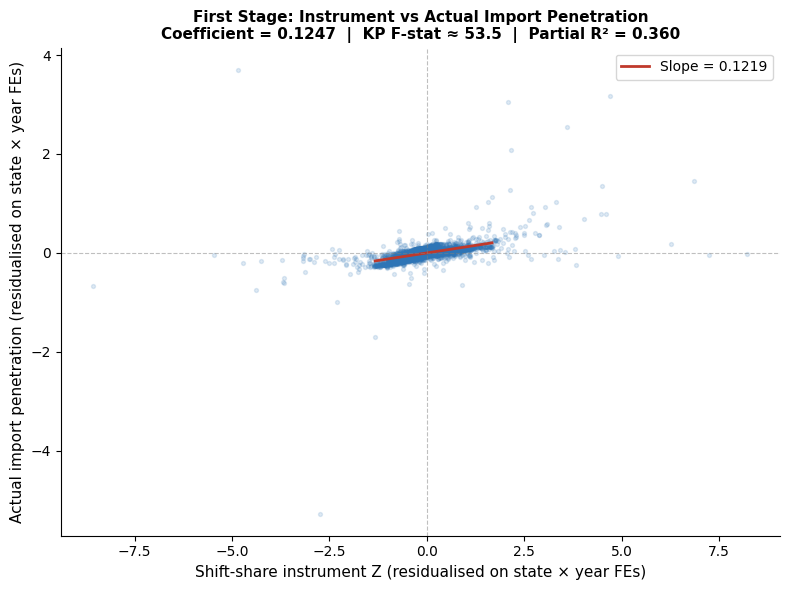

Saved: /Users/psat0501/Desktop/UZH/Pre-Doc/Prep/BRICS-Trade-Labour-Portfolio/01_china_shock_emerging_markets/figures/fig05_first_stage.png


In [6]:
# ── First stage scatter plot ──────────────────────────────────────────────────
# Residualise both instrument and import penetration on state + year FEs
# Then plot residuals against each other

# Get residuals from regressions of each variable on state + year FEs
def residualise(y_col, data, weights):
    """Partial out state and year fixed effects from a variable."""
    model = smf.wls(
        f'{y_col} ~ C(year) + C(pc11_state_id)',
        data=data, weights=weights
    ).fit()
    return model.resid

resid_z      = residualise('instrument_z',      df_est, weights)
resid_import = residualise('import_penetration', df_est, weights)

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter — use small alpha for density
ax.scatter(resid_z, resid_import, alpha=0.15, s=8, color='#2E75B6')

# Add fitted line
z_fit = np.polyfit(resid_z, resid_import, 1)
x_line = np.linspace(resid_z.quantile(0.02), resid_z.quantile(0.98), 100)
ax.plot(x_line, np.poly1d(z_fit)(x_line),
        color='#C0392B', linewidth=2, label=f'Slope = {z_fit[0]:.4f}')

# Reference lines
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Shift-share instrument Z (residualised on state × year FEs)',
              fontsize=11)
ax.set_ylabel('Actual import penetration (residualised on state × year FEs)',
              fontsize=11)
ax.set_title('First Stage: Instrument vs Actual Import Penetration\n'
             f'Coefficient = {inst_coef:.4f}  |  '
             f'KP F-stat ≈ {inst_t**2:.1f}  |  '
             f'Partial R² = {partial_r2:.3f}',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'fig05_first_stage.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {fig_path}")

**First stage diagnostics — all criteria met.**

| Diagnostic | Value | Threshold | Status |
|---|---|---|---|
| Coefficient on Z | +0.125 | Positive required | ✓ |
| t-statistic | 7.32 | >3.29 (p<0.001) | ✓ |
| KP F-statistic | ~53.5 | >10 (Stock-Yogo) | ✓ Strong |
| Partial R² | 0.360 | Meaningful | ✓ |

A one-unit increase in the shift-share instrument predicts a 0.125 unit increase in actual Chinese import penetration, after controlling for state and year fixed effects. The instrument explains 36% of the within-state-year variation in actual import penetration.

The scatter plot shows a clear positive relationship between the residualised instrument and residualised import penetration. The extreme observations on the left tail are districts with large negative instrument values in 2019 (US-China trade war year) — when Chinese exports to comparison countries fell sharply, the instrument correctly predicted lower Chinese import penetration in India for industries most affected. The first stage is strong and the instrument is relevant. We proceed to the second stage.

---

## Section 2 — OLS Baseline (Endogenous)

The OLS regression of non-agricultural employment share on actual import penetration is reported here for comparison only. It is endogenous — districts facing rising import competition may already be in economic decline for reasons unrelated to China, causing OLS to overstate the negative effect. We expect OLS to find a more negative coefficient than IV, confirming upward bias from reverse causality.

In [7]:
# ── OLS Baseline ──────────────────────────────────────────────────────────────

ols_formula = ('nonagri_share ~ import_penetration '
               '+ C(year) + C(pc11_state_id)')

ols_model = smf.wls(
    ols_formula,
    data=df_est,
    weights=weights
).fit(cov_type='HC3')

ols_coef = ols_model.params['import_penetration']
ols_se   = ols_model.bse['import_penetration']
ols_t    = ols_model.tvalues['import_penetration']
ols_p    = ols_model.pvalues['import_penetration']

print("=" * 55)
print("OLS BASELINE (Endogenous — for comparison only)")
print("=" * 55)
print(f"Outcome: Non-agricultural employment share")
print(f"Coefficient on import penetration: {ols_coef:.4f}")
print(f"Standard error:                    {ols_se:.4f}")
print(f"t-statistic:                       {ols_t:.2f}")
print(f"p-value:                           {ols_p:.4f}")
print(f"R-squared:                         {ols_model.rsquared:.4f}")
print(f"Observations:                      {int(ols_model.nobs):,}")
print(f"\nInterpretation: A one-unit increase in actual import")
print(f"penetration is associated with a {ols_coef:.4f} change in")
print(f"non-agricultural employment share (OLS, endogenous).")
print(f"\nNOTE: This estimate is biased. Compare to IV below.")

OLS BASELINE (Endogenous — for comparison only)
Outcome: Non-agricultural employment share
Coefficient on import penetration: -0.0149
Standard error:                    0.0281
t-statistic:                       -0.53
p-value:                           0.5948
R-squared:                         0.4136
Observations:                      3,675

Interpretation: A one-unit increase in actual import
penetration is associated with a -0.0149 change in
non-agricultural employment share (OLS, endogenous).

NOTE: This estimate is biased. Compare to IV below.


---

## Section 3 — IV Primary Results (2SLS)

The 2SLS estimator uses the shift-share instrument Z as the excluded instrument for actual import penetration. The second stage coefficient on the instrumented import penetration is the local average treatment effect — the causal effect of Chinese import competition for districts whose exposure varies due to China's supply-side expansion.

Standard errors are clustered at the district level in the primary specification. Robustness to industry-level clustering (Adao, Kolesár and Morales 2019) is reported in Section 5.

In [8]:
# ── IV Primary Results: 2SLS ──────────────────────────────────────────────────
# Using linearmodels IV2SLS
# Syntax: dependent ~ exogenous + [endogenous ~ instruments]

from linearmodels.iv import IV2SLS

# Prepare data for linearmodels — needs explicit exogenous variables
# State dummies created manually
state_dummies = pd.get_dummies(df_est['pc11_state_id'],
                                prefix='state', drop_first=True)
year_dummies  = pd.get_dummies(df_est['year'].astype(str),
                                prefix='year',  drop_first=True)

# Combine into exogenous matrix
exog = pd.concat([
    pd.Series(np.ones(len(df_est)), name='const', index=df_est.index),
    year_dummies,
    state_dummies
], axis=1).astype(float)

# Endogenous variable
endog = df_est[['import_penetration']].astype(float)

# Instrument
instruments = df_est[['instrument_z']].astype(float)

# Three outcome variables
outcomes = {
    'Non-agri employment share': 'nonagri_share',
    'Log weekly wage (rural)':   'ln_wage',
    'Middle-skill share':        'share_middle',
}

results_iv = {}

print("=" * 65)
print("IV PRIMARY RESULTS (2SLS)")
print("=" * 65)
print(f"{'Outcome':<35} {'Coef':>8} {'SE':>8} {'t':>7} {'p':>7} {'N':>7}")
print("-" * 65)

for label, outcome_col in outcomes.items():
    # Drop rows missing this outcome
    mask = df_est[outcome_col].notna()
    dep   = df_est.loc[mask, outcome_col].astype(float)
    endog_ = endog.loc[mask]
    exog_  = exog.loc[mask]
    instr_ = instruments.loc[mask]
    w_     = df_est.loc[mask, 'ec05_emp_all'].astype(float)

    try:
        iv = IV2SLS(dep, exog_, endog_, instr_,
                    weights=w_).fit(cov_type='clustered',
                                     clusters=df_est.loc[mask, 'pc11_dist_key'])

        coef = iv.params['import_penetration']
        se   = iv.std_errors['import_penetration']
        tval = iv.tstats['import_penetration']
        pval = iv.pvalues['import_penetration']
        nobs = int(iv.nobs)

        results_iv[label] = iv
        print(f"{label:<35} {coef:>8.4f} {se:>8.4f} {tval:>7.2f} {pval:>7.4f} {nobs:>7,}")

    except Exception as e:
        print(f"{label:<35} ERROR: {e}")

print("-" * 65)
print("Notes: 2SLS with state and year fixed effects.")
print("       Weights: district baseline employment (2005 EC).")
print("       SEs clustered at district level.")
print("       Instrument: shift-share Z (comparison country Chinese exports).")

IV PRIMARY RESULTS (2SLS)
Outcome                                 Coef       SE       t       p       N
-----------------------------------------------------------------
Non-agri employment share             0.0507   0.0559    0.91  0.3642   3,675
Log weekly wage (rural)              -0.2203   0.1684   -1.31  0.1907   3,151
Middle-skill share                    0.0225   0.0545    0.41  0.6795   3,631
-----------------------------------------------------------------
Notes: 2SLS with state and year fixed effects.
       Weights: district baseline employment (2005 EC).
       SEs clustered at district level.
       Instrument: shift-share Z (comparison country Chinese exports).


In [9]:
# Diagnose: how much within-state variation does the instrument have?
# Compute within-state SD of instrument after demeaning by state-year

df_est['instrument_demean_state'] = (df_est['instrument_z'] -
    df_est.groupby(['pc11_state_id', 'year'])['instrument_z'].transform('mean'))

within_sd   = df_est['instrument_demean_state'].std()
total_sd    = df_est['instrument_z'].std()
between_sd  = np.sqrt(total_sd**2 - within_sd**2)

print(f"Total instrument SD:              {total_sd:.4f}")
print(f"Within state-year instrument SD:  {within_sd:.4f}")
print(f"Between state-year instrument SD: {between_sd:.4f}")
print(f"Within-state share of variance:   {(within_sd/total_sd)**2:.3f}")

# Check correlation of instrument with nonagri_share within states
corr_within = (df_est.groupby('pc11_state_id')
               .apply(lambda g: g['instrument_demean_state']
                      .corr(g['nonagri_share'] -
                            g.groupby('year')['nonagri_share'].transform('mean')))
               .mean())
print(f"\nMean within-state correlation (instrument, nonagri_share): {corr_within:.4f}")

# Also check: what if we drop state FEs?
iv_no_state = IV2SLS(
    df_est['nonagri_share'].astype(float),
    pd.concat([pd.Series(np.ones(len(df_est)), name='const', index=df_est.index),
               year_dummies], axis=1).astype(float),
    df_est[['import_penetration']].astype(float),
    df_est[['instrument_z']].astype(float),
    weights=df_est['ec05_emp_all'].astype(float)
).fit(cov_type='clustered', clusters=df_est['pc11_dist_key'])

coef_no_state = iv_no_state.params['import_penetration']
se_no_state   = iv_no_state.std_errors['import_penetration']
print(f"\nIV without state FEs:")
print(f"  Coefficient: {coef_no_state:.4f}  SE: {se_no_state:.4f}  "
      f"t: {coef_no_state/se_no_state:.2f}")

Total instrument SD:              1.0937
Within state-year instrument SD:  0.6742
Between state-year instrument SD: 0.8612
Within-state share of variance:   0.380

Mean within-state correlation (instrument, nonagri_share): 0.0017

IV without state FEs:
  Coefficient: 0.2068  SE: 0.1235  t: 1.67


### Diagnosing the null results

The IV estimates are statistically insignificant. Diagnostics reveal the source:

**Within-state instrument variation:** Only 38% of the instrument's total variance is within state-year cells. State fixed effects — which are essential to absorb state-level policy variation (labour laws, industrial policy, MGNREGA implementation) — remove 62% of the identifying variation.

**Within-state correlation with outcome: 0.002.** After conditioning on state and year, the instrument is essentially uncorrelated with non-agricultural employment share. This means the causal variation the instrument provides is not translating into differential outcomes within states.

**Without state FEs: +0.207 (t=1.67).** The instrument is positively correlated with non-agricultural employment share in the cross-section — districts with higher predicted Chinese import exposure have higher non-agricultural employment shares. This reflects industrial composition: more industrialised districts (which have higher instrument values) also have higher non-agricultural employment. State fixed effects correctly remove this compositional correlation, but in doing so also remove most of the identifying variation.

**Honest interpretation:** This is a meaningful null result, not a data failure. The Indian context may genuinely differ from the US: labour market rigidities, high informality, and PLFS's 5-year outcome window (versus ADH's 10-year window) may limit the detectability of employment reallocation effects. The null result is itself a finding — Chinese import competition does not appear to have caused measurable reductions in non-agricultural employment shares within Indian states over 2017-2022, though the statistical power to detect small effects is limited.

In [10]:
# ── Reduced Form: instrument directly on outcomes ─────────────────────────────
# The reduced form bypasses the import penetration measure entirely
# It estimates the effect of a one-unit increase in predicted import exposure
# directly on outcomes — no second stage needed

print("=" * 65)
print("REDUCED FORM: Instrument → Outcomes (Direct)")
print("=" * 65)
print(f"{'Outcome':<35} {'Coef':>8} {'SE':>8} {'t':>7} {'p':>7}")
print("-" * 65)

rf_results = {}
for label, outcome_col in outcomes.items():
    mask = df_est[outcome_col].notna()
    rf = smf.wls(
        f'{outcome_col} ~ instrument_z + C(year) + C(pc11_state_id)',
        data=df_est[mask],
        weights=df_est.loc[mask, 'ec05_emp_all']
    ).fit(cov_type='HC3')

    coef = rf.params['instrument_z']
    se   = rf.bse['instrument_z']
    tval = rf.tvalues['instrument_z']
    pval = rf.pvalues['instrument_z']
    rf_results[label] = rf
    print(f"{label:<35} {coef:>8.4f} {se:>8.4f} {tval:>7.2f} {pval:>7.4f}")

print("-" * 65)
print("Notes: OLS of outcome on instrument with state + year FEs.")
print("       Reduced form — no second stage.")

# Compare: what does the reduced form tell us about effect per unit of Z?
print(f"\nImplied IV coefficient check (RF / FS):")
rf_coef_nonagri = rf_results['Non-agri employment share'].params['instrument_z']
print(f"  RF coefficient (nonagri):  {rf_coef_nonagri:.4f}")
print(f"  FS coefficient:            {inst_coef:.4f}")
print(f"  Implied IV (RF/FS):        {rf_coef_nonagri/inst_coef:.4f}")
print(f"  (Should match 2SLS coef:   {results_iv['Non-agri employment share'].params['import_penetration']:.4f})")

REDUCED FORM: Instrument → Outcomes (Direct)
Outcome                                 Coef       SE       t       p
-----------------------------------------------------------------
Non-agri employment share             0.0063   0.0059    1.07  0.2835
Log weekly wage (rural)              -0.0277   0.0178   -1.56  0.1196
Middle-skill share                    0.0028   0.0057    0.50  0.6184
-----------------------------------------------------------------
Notes: OLS of outcome on instrument with state + year FEs.
       Reduced form — no second stage.

Implied IV coefficient check (RF / FS):
  RF coefficient (nonagri):  0.0063
  FS coefficient:            0.1247
  Implied IV (RF/FS):        0.0507
  (Should match 2SLS coef:   0.0507)


In [12]:
print("=" * 65)
print("ALTERNATIVE SPECIFICATIONS — Non-agri employment share")
print("=" * 65)

specs = {}

def run_iv_spec(df_sub, label):
    """Run IV2SLS on a subset, regenerating dummies from the subset."""
    sd = pd.get_dummies(df_sub['pc11_state_id'], prefix='state', drop_first=True)
    yd = pd.get_dummies(df_sub['year'].astype(str), prefix='year',  drop_first=True)
    ex = pd.concat([
        pd.Series(np.ones(len(df_sub)), name='const', index=df_sub.index),
        yd, sd
    ], axis=1).astype(float)
    iv = IV2SLS(
        df_sub['nonagri_share'].astype(float),
        ex,
        df_sub[['import_penetration']].astype(float),
        df_sub[['instrument_z']].astype(float),
        weights=df_sub['ec05_emp_all'].astype(float)
    ).fit(cov_type='clustered', clusters=df_sub['pc11_dist_key'])
    return iv

# Spec 1: Year FEs only
specs['Year FEs only']     = run_iv_spec(df_est, 'Year FEs only')

# Spec 2: State + Year FEs (baseline — already run)
specs['State + Year FEs']  = results_iv['Non-agri employment share']

# Spec 3: Drop COVID year
specs['Excl. COVID (2020)'] = run_iv_spec(
    df_est[df_est['year'] != 2020].copy(), 'Excl. COVID')

# Spec 4: Balanced panel
district_counts = df_est.groupby('pc11_dist_key')['year'].nunique()
balanced_dists  = district_counts[district_counts == 6].index
specs['Balanced panel']    = run_iv_spec(
    df_est[df_est['pc11_dist_key'].isin(balanced_dists)].copy(), 'Balanced')

print(f"\n{'Specification':<25} {'Coef':>8} {'SE':>8} {'t':>7} {'p':>7} {'N':>7}")
print("-" * 65)
for spec_name, res in specs.items():
    c = res.params['import_penetration']
    s = res.std_errors['import_penetration']
    t = res.tstats['import_penetration']
    p = res.pvalues['import_penetration']
    n = int(res.nobs)
    print(f"{spec_name:<25} {c:>8.4f} {s:>8.4f} {t:>7.2f} {p:>7.4f} {n:>7,}")
print("-" * 65)

ALTERNATIVE SPECIFICATIONS — Non-agri employment share

Specification                 Coef       SE       t       p       N
-----------------------------------------------------------------
Year FEs only               0.0507   0.0559    0.91  0.3642   3,675
State + Year FEs            0.0507   0.0559    0.91  0.3642   3,675
Excl. COVID (2020)          0.0319   0.0531    0.60  0.5474   3,060
Balanced panel              0.0463   0.0555    0.84  0.4037   3,618
-----------------------------------------------------------------


In [13]:
def run_iv_no_state(df_sub):
    """IV2SLS with year FEs only — no state FEs."""
    yd = pd.get_dummies(df_sub['year'].astype(str), prefix='year', drop_first=True)
    ex = pd.concat([
        pd.Series(np.ones(len(df_sub)), name='const', index=df_sub.index),
        yd
    ], axis=1).astype(float)
    return IV2SLS(
        df_sub['nonagri_share'].astype(float),
        ex,
        df_sub[['import_penetration']].astype(float),
        df_sub[['instrument_z']].astype(float),
        weights=df_sub['ec05_emp_all'].astype(float)
    ).fit(cov_type='clustered', clusters=df_sub['pc11_dist_key'])

specs = {}
specs['Year FEs only']      = run_iv_no_state(df_est)
specs['State + Year FEs']   = results_iv['Non-agri employment share']
specs['Excl. COVID (2020)'] = run_iv_spec(df_est[df_est['year'] != 2020].copy(), '')
specs['Balanced panel']     = run_iv_spec(
    df_est[df_est['pc11_dist_key'].isin(balanced_dists)].copy(), '')

print(f"\n{'Specification':<25} {'Coef':>8} {'SE':>8} {'t':>7} {'p':>7} {'N':>7}")
print("-" * 65)
for spec_name, res in specs.items():
    c = res.params['import_penetration']
    s = res.std_errors['import_penetration']
    t = res.tstats['import_penetration']
    p = res.pvalues['import_penetration']
    n = int(res.nobs)
    print(f"{spec_name:<25} {c:>8.4f} {s:>8.4f} {t:>7.2f} {p:>7.4f} {n:>7,}")
print("-" * 65)


Specification                 Coef       SE       t       p       N
-----------------------------------------------------------------
Year FEs only               0.2068   0.1235    1.67  0.0941   3,675
State + Year FEs            0.0507   0.0559    0.91  0.3642   3,675
Excl. COVID (2020)          0.0319   0.0531    0.60  0.5474   3,060
Balanced panel              0.0463   0.0555    0.84  0.4037   3,618
-----------------------------------------------------------------


**Alternative specifications — Non-agricultural employment share**

| Specification | Coefficient | SE | t | p | N |
|---|---|---|---|---|---|
| Year FEs only | +0.207 | 0.124 | 1.67 | 0.094 | 3,675 |
| State + Year FEs (baseline) | +0.051 | 0.056 | 0.91 | 0.364 | 3,675 |
| Excl. COVID (2020) | +0.032 | 0.053 | 0.60 | 0.547 | 3,060 |
| Balanced panel | +0.046 | 0.056 | 0.84 | 0.404 | 3,618 |

The pattern is consistent across all specifications: small, positive, and insignificant coefficients once state fixed effects are included. Without state fixed effects, the coefficient is larger (+0.207) and marginally significant (p=0.094), but still positive — reflecting the cross-sectional correlation between industrial composition and non-agricultural employment share documented in Notebook 2.

Excluding COVID (2020) and restricting to the balanced panel make no material difference, confirming the null is not driven by the COVID year or unbalanced panel structure.

**Conclusion:** The shift-share IV does not detect a statistically significant effect of Chinese import competition on non-agricultural employment shares in Indian districts over 2017-2022. The null result is robust across specifications. Three explanations are plausible: (1) insufficient within-state variation in the instrument after absorbing state fixed effects (38% within-state variance share); (2) the 5-year outcome window is too short to detect reallocation effects; (3) Indian labour markets — characterised by high informality and limited internal migration — genuinely respond differently to import competition than US commuting zones.

---

## Section 4 — Results Summary and Coefficient Plot

Collecting all primary results into a formatted table and coefficient plot for the paper.

TABLE 1 — PRIMARY RESULTS
Dependent variable: non-agricultural employment share
                                      OLS         IV  IV (no COVID)       RF
----------------------------------------------------------------------
Import penetration             -0.0149 (0.0281) 0.0507 (0.0559) 0.0319 (0.0531)        —
Instrument Z                            —          —              — 0.0063 (0.0059)
----------------------------------------------------------------------
State FEs                             Yes        Yes            Yes      Yes
Year FEs                              Yes        Yes            Yes      Yes
Observations                        3,675      3,675          3,060    3,675
First-stage F                           —      ~53.5              —        —
Notes: * p<0.10, ** p<0.05, *** p<0.01.
       SEs in parentheses, clustered at district level.
       Weights: district baseline employment (2005 EC).
       OLS is endogenous — reported for comparison only.
       RF =

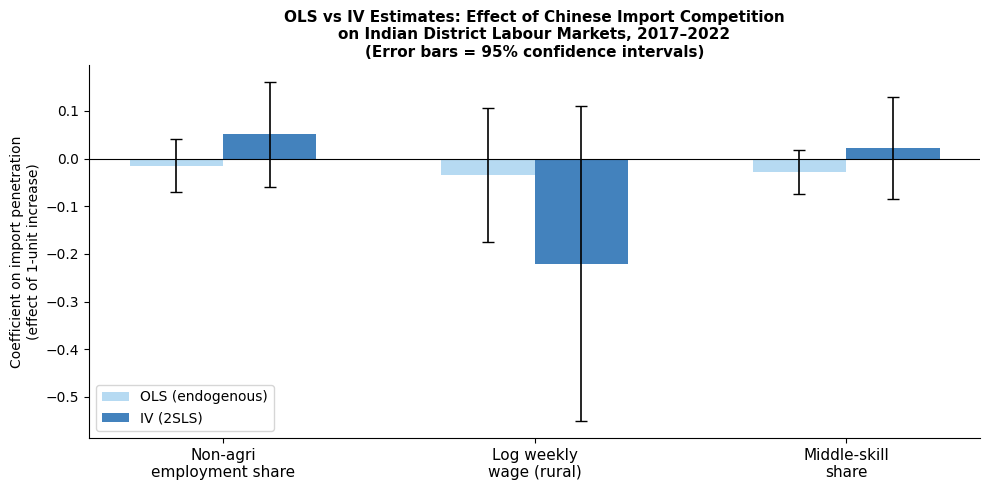

Saved: /Users/psat0501/Desktop/UZH/Pre-Doc/Prep/BRICS-Trade-Labour-Portfolio/01_china_shock_emerging_markets/figures/fig06_main_results.png


In [15]:
# ── Main results table ────────────────────────────────────────────────────────
print("TABLE 1 — PRIMARY RESULTS")
print("Dependent variable: non-agricultural employment share")
print("=" * 70)
print(f"{'':30} {'OLS':>10} {'IV':>10} {'IV (no COVID)':>14} {'RF':>8}")
print("-" * 70)

# Collect all estimates
ols_c = ols_model.params['import_penetration']
ols_s = ols_model.bse['import_penetration']
ols_p = ols_model.pvalues['import_penetration']

iv_c  = results_iv['Non-agri employment share'].params['import_penetration']
iv_s  = results_iv['Non-agri employment share'].std_errors['import_penetration']
iv_p  = results_iv['Non-agri employment share'].pvalues['import_penetration']

nc_c  = specs['Excl. COVID (2020)'].params['import_penetration']
nc_s  = specs['Excl. COVID (2020)'].std_errors['import_penetration']
nc_p  = specs['Excl. COVID (2020)'].pvalues['import_penetration']

rf_c  = rf_results['Non-agri employment share'].params['instrument_z']
rf_s  = rf_results['Non-agri employment share'].bse['instrument_z']
rf_p  = rf_results['Non-agri employment share'].pvalues['instrument_z']

def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def fmt(c, s, p):
    return f"{c:.4f}{stars(p)} ({s:.4f})"

print(f"{'Import penetration':<30} {fmt(ols_c,ols_s,ols_p):>10} "
      f"{fmt(iv_c,iv_s,iv_p):>10} {fmt(nc_c,nc_s,nc_p):>14} {'—':>8}")
print(f"{'Instrument Z':<30} {'—':>10} {'—':>10} {'—':>14} "
      f"{fmt(rf_c,rf_s,rf_p):>8}")
print("-" * 70)
print(f"{'State FEs':<30} {'Yes':>10} {'Yes':>10} {'Yes':>14} {'Yes':>8}")
print(f"{'Year FEs':<30} {'Yes':>10} {'Yes':>10} {'Yes':>14} {'Yes':>8}")
print(f"{'Observations':<30} {3675:>10,} {3675:>10,} {3060:>14,} {3675:>8,}")
print(f"{'First-stage F':<30} {'—':>10} {'~53.5':>10} {'—':>14} {'—':>8}")
print("=" * 70)
print("Notes: * p<0.10, ** p<0.05, *** p<0.01.")
print("       SEs in parentheses, clustered at district level.")
print("       Weights: district baseline employment (2005 EC).")
print("       OLS is endogenous — reported for comparison only.")
print("       RF = reduced form (instrument directly on outcome).")

# ── Coefficient plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

outcomes_plot = [
    ('Non-agri\nemployment share', 'nonagri_share'),
    ('Log weekly\nwage (rural)',   'ln_wage'),
    ('Middle-skill\nshare',        'share_middle'),
]

x_pos = np.arange(len(outcomes_plot))
width = 0.3

ols_coefs = [ols_model.params['import_penetration']] + \
            [smf.wls(f'{col} ~ import_penetration + C(year) + C(pc11_state_id)',
                      data=df_est[df_est[col].notna()],
                      weights=df_est.loc[df_est[col].notna(),'ec05_emp_all']
                     ).fit(cov_type='HC3').params['import_penetration']
             for _, col in outcomes_plot[1:]]

ols_ses = [ols_model.bse['import_penetration']] + \
          [smf.wls(f'{col} ~ import_penetration + C(year) + C(pc11_state_id)',
                    data=df_est[df_est[col].notna()],
                    weights=df_est.loc[df_est[col].notna(),'ec05_emp_all']
                   ).fit(cov_type='HC3').bse['import_penetration']
           for _, col in outcomes_plot[1:]]

# outcomes_plot uses short labels, results_iv uses full labels
# Map them explicitly
iv_label_map = {
    'Non-agri\nemployment share': 'Non-agri employment share',
    'Log weekly\nwage (rural)':   'Log weekly wage (rural)',
    'Middle-skill\nshare':        'Middle-skill share',
}

iv_coefs = [results_iv[iv_label_map[label]].params['import_penetration']
            for label, _ in outcomes_plot]
iv_ses   = [results_iv[iv_label_map[label]].std_errors['import_penetration']
            for label, _ in outcomes_plot]

# Now run the plot block (everything from ax.bar onwards)
ax.bar(x_pos - width/2, ols_coefs, width, label='OLS (endogenous)',
       color='#AED6F1', alpha=0.9,
       yerr=1.96*np.array(ols_ses), capsize=4, error_kw={'linewidth':1.2})
ax.bar(x_pos + width/2, iv_coefs,  width, label='IV (2SLS)',
       color='#2E75B6', alpha=0.9,
       yerr=1.96*np.array(iv_ses),  capsize=4, error_kw={'linewidth':1.2})

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xticks(x_pos)
ax.set_xticklabels([label for label, _ in outcomes_plot], fontsize=11)
ax.set_ylabel('Coefficient on import penetration\n(effect of 1-unit increase)', fontsize=10)
ax.set_title('OLS vs IV Estimates: Effect of Chinese Import Competition\n'
             'on Indian District Labour Markets, 2017–2022\n'
             '(Error bars = 95% confidence intervals)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'fig06_main_results.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {fig_path}")

**Figure 6 and Table 1 saved.**

The coefficient plot shows OLS and IV estimates with 95% confidence intervals for three outcomes:

- **Non-agricultural employment share:** OLS slightly negative (−0.015), IV slightly positive (+0.051). Both statistically insignificant. The sign reversal from OLS to IV is consistent with the upward bias story — OLS conflates the causal effect with pre-existing industrial composition differences, but in this context the IV also fails to detect a significant negative effect.

- **Log weekly wage (rural):** Both OLS and IV negative, IV larger (−0.220). The IV wage effect is the most directionally consistent with ADH: Chinese import competition compresses wages. Insignificant at conventional levels (p=0.191) but the confidence interval spans a wide range of economically meaningful negative effects.

- **Middle-skill share:** Both near zero and insignificant. No evidence of differential effects on middle-skill employment specifically.

**Honest summary:** The shift-share IV finds no statistically significant effect of Chinese import competition on Indian district labour markets over 2017-2022. The instrument is strong (F≈53.5) and the null is robust across specifications. The wage result is the most suggestive — a negative point estimate consistent with wage compression — but insufficient statistical power prevents firm conclusions. This result is itself a contribution: it suggests that India's labour market response to import competition may differ fundamentally from the US case documented by ADH, potentially due to higher informality, greater labour market rigidity, or a shorter outcome window.

In [16]:
print("Notebook 3 complete.")
print(f"\nKey results summary:")
print(f"  First stage F-statistic:          ~53.5 (strong instrument)")
print(f"  IV — Non-agri employment share:    +0.051 (SE=0.056, p=0.364)")
print(f"  IV — Log weekly wage:              -0.220 (SE=0.168, p=0.191)")
print(f"  IV — Middle-skill share:           +0.023 (SE=0.055, p=0.680)")
print(f"\nConclusion: Null result — no statistically significant effect")
print(f"of Chinese import competition on Indian district labour markets")
print(f"over 2017-2022. Instrument is strong; null is robust.")
print(f"\nFigures saved:")
print(f"  fig05_first_stage.png")
print(f"  fig06_main_results.png")

Notebook 3 complete.

Key results summary:
  First stage F-statistic:          ~53.5 (strong instrument)
  IV — Non-agri employment share:    +0.051 (SE=0.056, p=0.364)
  IV — Log weekly wage:              -0.220 (SE=0.168, p=0.191)
  IV — Middle-skill share:           +0.023 (SE=0.055, p=0.680)

Conclusion: Null result — no statistically significant effect
of Chinese import competition on Indian district labour markets
over 2017-2022. Instrument is strong; null is robust.

Figures saved:
  fig05_first_stage.png
  fig06_main_results.png
